In [1]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer
import numpy as np
import os
import math
import random
from dataclasses import dataclass
from collections import defaultdict
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torchcrf import CRF
import spacy
from tqdm.auto import tqdm
import re

/home/omer_ahmed/Experiments/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ARTICLES_FOLDER = "PTC/train-articles"   
LABEL_FILE = "PTC/train-task2-TC.labels" 

In [3]:
def build_ptc_dataset(articles_folder: str, labels_file: str) -> pd.DataFrame:

    # -------------------------
    # 1. Read labels file
    # -------------------------
    labels_df = pd.read_csv(
        labels_file,
        sep="\t",
        header=None,
        names=["article_id","techniques","span_start", "span_end"]
    )

    labels_df["article_id"] = labels_df["article_id"].astype(str)
    # -------------------------
    # 2. Read all articles
    # -------------------------
    articles_dict = {}

    for filename in os.listdir(articles_folder):
        if filename.endswith(".txt"):
            article_id = filename.replace("article", "").replace(".txt", "")
            file_path = os.path.join(articles_folder, filename)

            with open(file_path, "r", encoding="utf-8") as f:
                articles_dict[article_id] = f.read()

    # -------------------------
    # 3. Merge labels + articles
    # -------------------------
    dataset_rows = []

    for _, row in labels_df.iterrows():
        article_id = row["article_id"]

        if article_id in articles_dict:
            article_text = articles_dict[article_id]
            start = int(row["span_start"])
            end = int(row["span_end"])

            dataset_rows.append({
                "article_id": article_id,
                "article_text": article_text,
                "span_start": start,
                "span_end": end,
                "span_text": article_text[start:end],
                "technique": row["techniques"]

            })

    dataset = pd.DataFrame(dataset_rows)

    return dataset

In [4]:
PTC = build_ptc_dataset(ARTICLES_FOLDER, LABEL_FILE)

In [5]:
def collapse_to_multilabel_spans(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    grouped = (
        df.groupby(["article_id", "span_start", "span_end"], as_index=False)
          .agg(
              article_text=("article_text", "first"),
              span_text=("span_text", "first"),
              techniques=("technique", lambda x: sorted(set(x)))
          )
    )
    return grouped

PTC_spans = collapse_to_multilabel_spans(PTC)

In [6]:
protext = pd.read_excel("ProText/ProText.xlsx")
protext.drop(columns=["Ur"], inplace=True)
protext


,Id,Span,Context,Techniques
0,1,rocket,Trump—is that blue-collar wages have begun to ...,Loaded_Language
1,2,illegal alien,"Now, with regard to Saris, she has no authorit...",Repetition
2,3,those ignorant Vatican translators,"Thus, continence cannot realistically be expec...","Name_Calling,Labeling"
3,4,an “extremist,"Instead, if they have taken any notice of him ...","Name_Calling,Labeling"
4,5,vilify and humiliate,It must be exacted from him directly in order ...,Loaded_Language
...,...,...,...,...
11527,11528,‘Neo-Nazi’,Ukraine’s ‘Neo-Nazi’ Battalion 10 Is Greasing ...,Reduction ad hitlerum
11528,11529,research results in a scarcity of,The lack of interest 6 in this research resul...,"Exaggeration, minimization"
11529,11530,"column Dad Bod, face a whole raft","Trans men trying to conceive, as documented by...","Exaggeration, minimization"
11530,11531,who would rather focus on life-threatening,"According to Pacey, this lack of interest in m...",Appeal to fear prejudice


In [7]:
# Updated to match PTC strings exactly
FINAL_LIST = [
    "Loaded_Language", 
    "Name_Calling,Labeling", 
    "Repetition", 
    "Exaggeration,Minimisation",  # PTC uses 's'
    "Doubt", 
    "Appeal_to_fear-prejudice", 
    "Slogans", 
    "Flag-Waving", 
    "Causal_Oversimplification", 
    "Appeal_to_Authority", 
    "Black-and-White_Fallacy", 
    "Thought-terminating_Cliches",
    "Whataboutism,Straw_Men,Red_Herring",
    "Bandwagon,Reductio_ad_hitlerum"
]

def harmonize_protext_to_ptc_format(df: pd.DataFrame) -> pd.DataFrame:
    # 1. Drop rows with missing techniques
    df = df.dropna().copy()
    
    # 2. Mapping Dictionary: Standardizing protext variants to PTC strings
    # Keys are lowercase/cleaned versions from protext, values are exact PTC strings
    ptc_mapping = {
        "loaded language": "Loaded_Language",
        "name calling,labeling": "Name_Calling,Labeling",
        "name calling, labeling": "Name_Calling,Labeling",
        "repetition": "Repetition",
        "exaggeration, minimization": "Exaggeration,Minimisation",
        "exaggeration, minimisation": "Exaggeration,Minimisation",
        "doubt": "Doubt",
        "appeal to fear prejudice": "Appeal_to_fear-prejudice",
        "appeal to fear-prejudice": "Appeal_to_fear-prejudice",
        "slogans": "Slogans",
        "flag waving": "Flag-Waving",
        "flag-waving": "Flag-Waving",
        "flag wavings": "Flag-Waving",
        "causal oversimplification": "Causal_Oversimplification",
        "appeal to authority": "Appeal_to_Authority",
        "black and white fallacy": "Black-and-White_Fallacy",
        "black-and-white fallacy": "Black-and-White_Fallacy",
        "thought terminating cliches": "Thought-terminating_Cliches",
        "thought-terminating cliches": "Thought-terminating_Cliches",
        
        # Merged/Bundle mappings
        "whataboutism": "Whataboutism,Straw_Men,Red_Herring",
        "straw men": "Whataboutism,Straw_Men,Red_Herring",
        "red herring": "Whataboutism,Straw_Men,Red_Herring",
        "whataboutism, straw men, red herring": "Whataboutism,Straw_Men,Red_Herring",
        
        "bandwagon": "Bandwagon,Reductio_ad_hitlerum",
        "reductio ad hitlerum": "Bandwagon,Reductio_ad_hitlerum",
        "reduction ad hitlerum": "Bandwagon,Reductio_ad_hitlerum",
        "bandwagon, reductio ad hitlerum": "Bandwagon,Reductio_ad_hitlerum"
    }

    def clean_to_ptc(val):
        # Initial cleanup of the protext string
        clean_val = str(val).replace("_", " ").strip().lower()
        clean_val = re.sub(r'\s+', ' ', clean_val)
        
        # Return mapped PTC string, or the value itself if not found
        return ptc_mapping.get(clean_val, val)

    # Apply the transformation
    df["Techniques"] = df["Techniques"].apply(clean_to_ptc)

    # 3. Strict Filtering
    # Remove any techniques (like 's' or 'Label') that don't match the PTC FINAL_LIST
    df = df[df["Techniques"].isin(FINAL_LIST)].reset_index(drop=True)
    
    print(f"✅ Protext techniques aligned to PTC format.")
    return df

# Execute
protext = harmonize_protext_to_ptc_format(protext)

# Final Verification
print("Unique Techniques in Protext (Matching PTC):")
print(protext["Techniques"].unique())

✅ Protext techniques aligned to PTC format.
Unique Techniques in Protext (Matching PTC):
<ArrowStringArray>
[                   'Loaded_Language',                         'Repetition',
              'Name_Calling,Labeling',          'Exaggeration,Minimisation',
           'Appeal_to_fear-prejudice',                            'Slogans',
                              'Doubt',                        'Flag-Waving',
     'Bandwagon,Reductio_ad_hitlerum',            'Black-and-White_Fallacy',
          'Causal_Oversimplification',                'Appeal_to_Authority',
        'Thought-terminating_Cliches', 'Whataboutism,Straw_Men,Red_Herring']
Length: 14, dtype: str


In [8]:
def align_protext_to_ptc(df: pd.DataFrame) -> pd.DataFrame:
    # 1. Standardize column names first
    # Mapping based on your images: Context -> article_text, Span -> span_text
    rename_map = {
        "Id": "article_id",
        "Context": "article_text",
        "Span": "span_text",
        "Techniques": "techniques"
    }
    df = df.rename(columns=rename_map)

    # 2. Type Safety: Ensure text columns are strings and article_id is string
    df["article_id"] = df["article_id"].astype(str)
    df["article_text"] = df["article_text"].astype(str)
    df["span_text"] = df["span_text"].astype(str)

    # 3. Calculate character offsets (span_start and span_end)
    def find_offsets(row):
        text = row["article_text"]
        span = row["span_text"]
        
        # .find() returns the start index of the first occurrence
        start = text.find(span)
        
        if start == -1:
            # Handle cases where the span might not be found exactly (e.g., encoding issues)
            return pd.Series([None, None])
            
        end = start + len(span)
        return pd.Series([start, end])

    # Add the new columns
    df[["span_start", "span_end"]] = df.apply(find_offsets, axis=1)

    # 4. Filter out any spans that couldn't be located in the text
    initial_len = len(df)
    df = df.dropna(subset=["span_start", "span_end"])
    df["span_start"] = df["span_start"].astype(int)
    df["span_end"] = df["span_end"].astype(int)
    
    if len(df) < initial_len:
        print(f"⚠️ Dropped {initial_len - len(df)} rows where span could not be located in text.")

    # 5. Convert technique strings into lists to match PTC multilabel format
    df["techniques"] = df["techniques"].apply(lambda x: [x] if isinstance(x, str) else x)

    # 6. Reorder columns to match the PTC image exactly
    column_order = ["article_id", "span_start", "span_end", "article_text", "span_text", "techniques"]
    df = df[column_order]

    return df

# Execute the alignment
protext_aligned = align_protext_to_ptc(protext)

⚠️ Dropped 188 rows where span could not be located in text.


In [9]:
protext_aligned

,article_id,span_start,span_end,article_text,span_text,techniques
0,1,46,52,Trump—is that blue-collar wages have begun to ...,rocket,[Loaded_Language]
1,2,100,113,"Now, with regard to Saris, she has no authorit...",illegal alien,[Repetition]
2,3,379,413,"Thus, continence cannot realistically be expec...",those ignorant Vatican translators,"[Name_Calling,Labeling]"
3,4,100,113,"Instead, if they have taken any notice of him ...",an “extremist,"[Name_Calling,Labeling]"
4,5,49,69,It must be exacted from him directly in order ...,vilify and humiliate,[Loaded_Language]
...,...,...,...,...,...,...
11223,11527,78,103,They don't treat us equally. I think they are ...,yourself they slap you.9,[Loaded_Language]
11224,11528,10,21,Ukraine’s ‘Neo-Nazi’ Battalion 10 Is Greasing ...,‘Neo-Nazi’,"[Bandwagon,Reductio_ad_hitlerum]"
11225,11529,32,65,The lack of interest 6 in this research resul...,research results in a scarcity of,"[Exaggeration,Minimisation]"
11226,11530,83,116,"Trans men trying to conceive, as documented by...","column Dad Bod, face a whole raft","[Exaggeration,Minimisation]"


In [23]:
final_df = pd.concat([PTC_spans, protext_aligned], ignore_index=True)

# 2. Final Sanity Check
print(f"✅ Merged Dataset 'final_df' Created.")
print(f"📊 Total Rows: {len(final_df)}")
print(f"📂 PTC Rows: {len(PTC_spans)} | Protext Rows: {len(protext_aligned)}")

# 3. Verify that 'techniques' is consistently a list of strings
# This is crucial for your multi-label classification logic
sample_idx = len(PTC_spans) + 1 # Pick a row that came from protext
print(f"\nSample 'techniques' format (Row {sample_idx}):", final_df.loc[sample_idx, "techniques"])
print("Type check:", type(final_df.loc[sample_idx, "techniques"]))
final_df

✅ Merged Dataset 'final_df' Created.
📊 Total Rows: 17128
📂 PTC Rows: 6087 | Protext Rows: 11041

Sample 'techniques' format (Row 6088): ['Repetition']
Type check: <class 'list'>


,article_id,span_start,span_end,article_text,span_text,techniques
0,111111111,149,157,Next plague outbreak in Madagascar could be 's...,appeared,[Doubt]
1,111111111,265,323,Next plague outbreak in Madagascar could be 's...,The next transmission could be more pronounced...,[Appeal_to_Authority]
2,111111111,1069,1091,Next plague outbreak in Madagascar could be 's...,"a very, very different",[Repetition]
3,111111111,1334,1462,Next plague outbreak in Madagascar could be 's...,He also pointed to the presence of the pneumon...,[Appeal_to_fear-prejudice]
4,111111111,1577,1616,Next plague outbreak in Madagascar could be 's...,but warned that the danger was not over,[Appeal_to_fear-prejudice]
...,...,...,...,...,...,...
17123,11527,78,103,They don't treat us equally. I think they are ...,yourself they slap you.9,[Loaded_Language]
17124,11528,10,21,Ukraine’s ‘Neo-Nazi’ Battalion 10 Is Greasing ...,‘Neo-Nazi’,"[Bandwagon,Reductio_ad_hitlerum]"
17125,11529,32,65,The lack of interest 6 in this research resul...,research results in a scarcity of,"[Exaggeration,Minimisation]"
17126,11530,83,116,"Trans men trying to conceive, as documented by...","column Dad Bod, face a whole raft","[Exaggeration,Minimisation]"


In [24]:
def split_by_article_id(
    df_spans: pd.DataFrame,
    train_size=0.8,
    val_size=0.2,
    random_state=42
):
    """
    Split one-row-per-span dataframe by article_id so that all rows
    from the same article remain in the same split.
    """

    if not (0 < train_size < 1):
        raise ValueError("train_size must be between 0 and 1")
    if not (0 <= val_size < 1):
        raise ValueError("val_size must be between 0 and 1")
    if train_size + val_size > 1:
        raise ValueError("train_size + val_size must be less than 1")

    test_size = 1.0 - train_size - val_size

    # Convert to plain Python list to avoid Arrow dtype issues
    article_ids = (
        df_spans["article_id"]
        .astype(str)
        .drop_duplicates()
        .tolist()
    )

    # First split: train vs temp
    train_articles, temp_articles = train_test_split(
        article_ids,
        train_size=train_size,
        random_state=random_state,
        shuffle=True
    )
    val_articles= temp_articles


    train_articles = set(train_articles)
    val_articles = set(val_articles)

    train_df = df_spans[df_spans["article_id"].astype(str).isin(train_articles)].copy()
    val_df = df_spans[df_spans["article_id"].astype(str).isin(val_articles)].copy()

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
    )
train_spans, val_spans = split_by_article_id(
    final_df,
    train_size=0.8,
    val_size=0.2,
    random_state=42
)

print("Train:", len(train_spans))
print("Validation:", len(val_spans))

print("Train articles:", train_spans["article_id"].nunique())
print("Validation articles:", val_spans["article_id"].nunique())

Train: 13953
Validation: 3175
Train articles: 9118
Validation articles: 2280


In [25]:
train_ids = set(train_spans["article_id"].astype(str).unique())
val_ids = set(val_spans["article_id"].astype(str).unique())

print("Train ∩ Val:", len(train_ids & val_ids))

Train ∩ Val: 0


In [26]:
def show_split_label_balance(train_df, val_df):
    def count_labels(df):
        return df["techniques"].explode().value_counts()

    balance = pd.DataFrame({
        "train": count_labels(train_df),
        "val": count_labels(val_df),
    }).fillna(0).astype(int)

    return balance.sort_index()

balance_df = show_split_label_balance(train_spans, val_spans)
print(balance_df)

                                    train   val
techniques                                     
Appeal_to_Authority                   321    60
Appeal_to_fear-prejudice              714   150
Bandwagon,Reductio_ad_hitlerum        217    59
Black-and-White_Fallacy               223    48
Causal_Oversimplification             450   104
Doubt                                1263   287
Exaggeration,Minimisation            1092   238
Flag-Waving                           762   213
Loaded_Language                      4731  1053
Name_Calling,Labeling                2250   482
Repetition                           1146   301
Slogans                               322    77
Thought-terminating_Cliches           178    31
Whataboutism,Straw_Men,Red_Herring    321    76


In [27]:
train_data = train_spans.copy()
# train_data.drop(columns=["techniques"], inplace=True)
val_data = val_spans.copy()
# val_data.drop(columns=["techniques"], inplace=True)

In [28]:
OUTPUT_DIR = "/home/omer_ahmed/Experiments/Span-models/processed_span_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_data.to_parquet(f"{OUTPUT_DIR}/train.parquet", index=False)
val_data.to_parquet(f"{OUTPUT_DIR}/val.parquet", index=False)
print(" Span detection datasets saved.")

 Span detection datasets saved.


/tmp/ipykernel_3263242/886428389.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_3263242/886428389.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


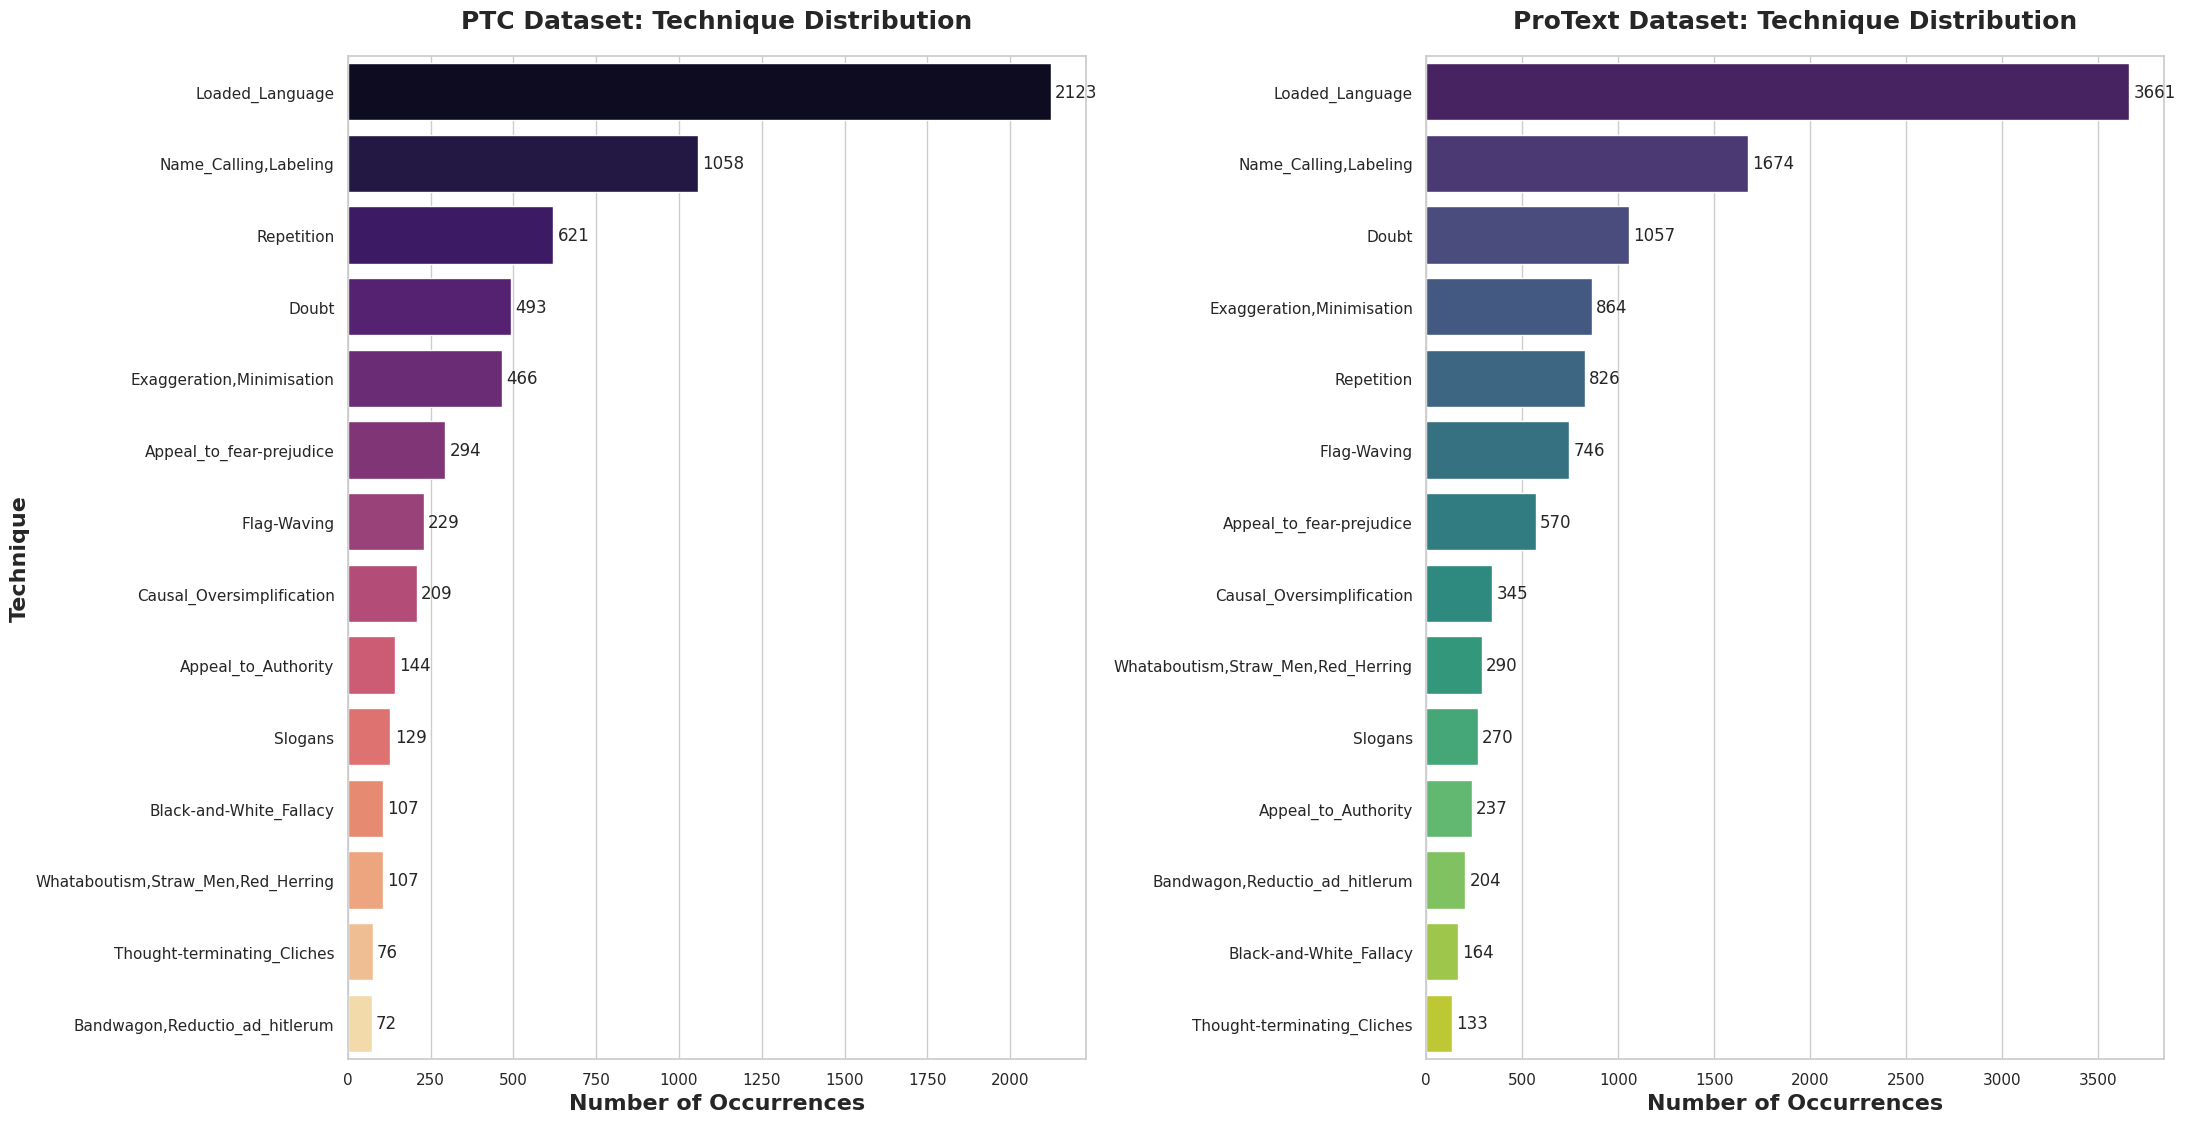

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 12))

# --- 1. Plot for PTC Dataset ---
exploded_ptc = PTC_spans.explode('techniques')
sns.countplot(
    data=exploded_ptc, 
    y='techniques', 
    order=exploded_ptc['techniques'].value_counts().index, 
    palette="magma",
    ax=ax1
)

# Bold labels and larger subtitle
ax1.set_title('PTC Dataset: Technique Distribution', fontsize=18, fontweight='bold', pad=20)
ax1.set_xlabel('Number of Occurrences', fontsize=16, fontweight='bold')
ax1.set_ylabel('Technique', fontsize=16, fontweight='bold')

# Add the count values on the bars
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontsize=12)

# --- 2. Plot for ProText Dataset ---
exploded_protext = protext_aligned.explode('techniques')
sns.countplot(
    data=exploded_protext, 
    y='techniques', 
    order=exploded_protext['techniques'].value_counts().index, 
    palette="viridis",
    ax=ax2
)

# Bold labels and larger subtitle
ax2.set_title('ProText Dataset: Technique Distribution', fontsize=18, fontweight='bold', pad=20)
ax2.set_xlabel('Number of Occurrences', fontsize=16, fontweight='bold')
ax2.set_ylabel('') # Keep empty as requested for side-by-side clarity

# Add the count values on the bars
for container in ax2.containers:
    ax2.bar_label(container, padding=3, fontsize=12)

# --- 3. Main Figure Title ---
fig.suptitle('Comparative Frequency Analysis of Propaganda Techniques', 
             fontsize=24, fontweight='bold', y=1.02)

# Adjust layout to prevent overlapping and leave room for suptitle
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()